#Measure of central Tendency & Dispeersion


Mean,Median,Mode

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('C:/Users/Lenovo/Desktop/maths exam/students_scores.csv')
df



,Student_ID,Age,Math_Score,Science_Score,English_Score,Hours_Studied,Pass_Fail
0,STU_10000,17,52,63,55,12.9,1
1,STU_10001,18,20,36,28,1.3,0
2,STU_10002,16,50,25,33,5.4,0
3,STU_10003,18,56,66,52,9.1,1
4,STU_10004,18,48,44,51,1.9,0
...,...,...,...,...,...,...,...
4995,STU_14995,15,28,36,48,1.5,0
4996,STU_14996,16,33,58,41,5.1,0
4997,STU_14997,15,55,42,52,10.8,0
4998,STU_14998,19,33,35,58,6.0,0


In [13]:
mean=np.mean(df['Math_Score'])
median=np.median (df['Math_Score'])
mode=df['Math_Score'].mode()[0]
print('Mean is',mean)
print('Median is',median)
print('Mode is',mode)

Mean is 51.3446
Median is 51.0
Mode is 44


Range,Variance,Standard deviation

In [16]:
satandard_d=np.std(df['Science_Score'])
print('Standard deviation is',satandard_d)

variance=np.var(df['Science_Score'])
print('Variance is',variance)

range=np.max(df['Science_Score'])- np.min(df['Science_Score'])
print('Range is',range)

Standard deviation is 12.789192962810416
Variance is 163.5634566399995
Range is 87


# Probability Basics

find probability of student passing 

In [18]:
p=len(df[df['Pass_Fail']==1])/len(df)
print('student passing probability is',round(p*100,2),)


student passing probability is 58.74


contingeency table betwen pass_fail and hours_studied>5

In [21]:
contingeency_table=pd.crosstab(df['Pass_Fail'],df['Hours_Studied']>5,margins=True)
contingeency_table

Hours_Studied,False,True,All
Pass_Fail,,,
0,923,1140,2063
1,221,2716,2937
All,1144,3856,5000


conditional probability p(pass| hours_studied>5)

In [23]:
ps=df[df['Hours_Studied']>5]  
# studied > 5
P_A_and_ps=df[(df['Pass_Fail']==1) & (df['Hours_Studied']>5)]
p=len(P_A_and_ps)/len(ps)
print('conditional probability is',round(p*100,2))


conditional probability is 70.44


# Distribution & Visualization

Histogram & Normal curve for math_score

(array([  2.,   3.,  12.,  30.,  73., 199., 353., 528., 694., 575., 711.,
        642., 431., 309., 186., 125.,  63.,  31.,  20.,  13.]),
 array([  2. ,   6.9,  11.8,  16.7,  21.6,  26.5,  31.4,  36.3,  41.2,
         46.1,  51. ,  55.9,  60.8,  65.7,  70.6,  75.5,  80.4,  85.3,
         90.2,  95.1, 100. ]),
 <BarContainer object of 20 artists>)

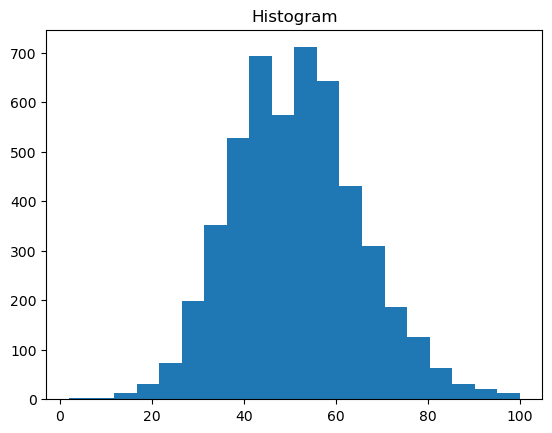

In [35]:
import matplotlib.pyplot as plt
from scipy.stats import norm

m_score=df['Math_Score']
plt.title("Histogram")
plt.hist(m_score, bins=20)


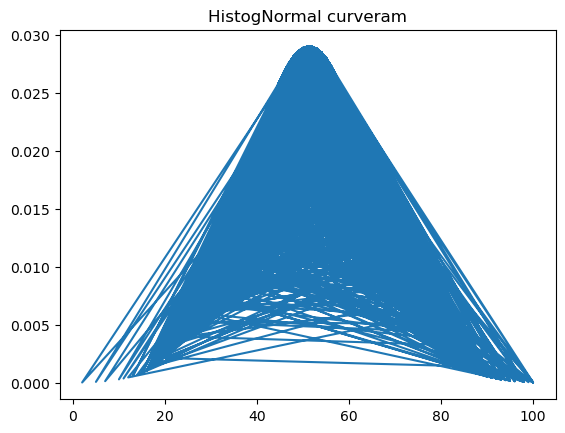

In [33]:
s_dev=np.std(df['Math_Score'])
x = norm.pdf(m_score, mean, s_dev)
plt.title("HistogNormal curveram")
plt.plot(m_score, x)

Skewness & Kurtosis for science_score

In [37]:
s=df['Science_Score'].skew()
k=df['Science_Score'].kurt()
print('skewness is',s)
print('kurtosis is',k)

if s > 0:
    print("  positively skewed")
elif s < 0:
    print("  negatively skewed")
else:
    print("symmetric distribution")

if k > 0:
    print(" positive kurtosis")
elif k < 0:
    print(" negative kurtosis")
else:
    print("normal kurtosis")

skewness is 0.2923601413461735
kurtosis is 0.25572483054889483
  positively skewed
 positive kurtosis


Q-Q plot

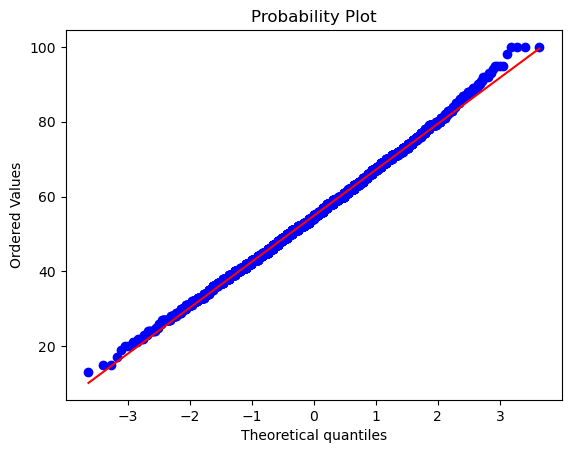

In [38]:
import scipy.stats as stats

stats.probplot(df["English_Score"], dist="norm", plot=plt)
plt.show()


# Linear Algebra  

Math_score & Science_score of first 5 student as vectors

In [49]:
s1=['Math_Score']
vector_maths=[]
vector_science=[]
s2=['Science_Score']
 
for i in range(0,5):
  vec1=df.loc[i,s1].astype(float).tolist()
  vec2=df.loc[i,s2].astype(float).tolist()
  vector_science.append(vec2)

  vector_maths.append(vec1)
print(vector_maths)
print(vector_science)

[[52.0], [20.0], [50.0], [56.0], [48.0]]
[[63.0], [36.0], [25.0], [66.0], [44.0]]


Dot produc of two vectors

In [52]:
a=np.array(vector_maths)
b=np.array(vector_science)
b=np.transpose(b)
dot_product=np.dot(a,b)
print(dot_product)

[[3276. 1872. 1300. 3432. 2288.]
 [1260.  720.  500. 1320.  880.]
 [3150. 1800. 1250. 3300. 2200.]
 [3528. 2016. 1400. 3696. 2464.]
 [3024. 1728. 1200. 3168. 2112.]]


Norm 1 and Norm 2 of math_score vector

In [54]:
n1=np.linalg.norm(vector_science,ord=1)
n2=np.linalg.norm(vector_science,ord=2)
print(n1)
print(round(n2,2))


234.0
110.37


Angle between tow vectors

In [55]:
m_vector = df.loc[0:4, "Math_Score"].values
s_vector = df.loc[0:4, "Science_Score"].values

print("Math Vector:", m_vector)
print("Science Vector:", s_vector)

dot = np.dot(m_vector, s_vector)

print("Dot Product:", dot)

mag_math = np.linalg.norm(m_vector)
mag_science = np.linalg.norm(s_vector)
print('magnitude of maths vector:',mag_math)
print('magnitude of science vector:',mag_science)

cos_theta = dot / (mag_math * mag_science)

print("Cos Theta:", cos_theta)

angle=np.degrees(np.arccos(cos_theta))
print('angle between two vectors is',angle)

Math Vector: [52 20 50 56 48]
Science Vector: [63 36 25 66 44]
Dot Product: 11054
magnitude of maths vector: 105.09043724335721
magnitude of science vector: 110.37209792334292
Cos Theta: 0.9530089158312101
angle between two vectors is 17.63440743816493
